# OceanEmbed — Full Training + Evaluation Pipeline (SIH PS 26066)
### Team: Satyam Gupta, Shivansh, Ayush, Sudipto, Khagesh, Muskan
**Status:** `READY_WITH_TRANSPARENT_CAVEATS` | Model Frozen 2026-09-12

This notebook contains the complete OceanEmbed pipeline:
1. Data loading from canonical processed cube
2. Chronological train/holdout split (no shuffling)
3. Feature engineering (7-day temporal window, 70 channels)
4. Model architecture (OceanEmbed-v3-Strengthened, regime-aware)
5. Training (anomaly regression + Gaussian NLL uncertainty)
6. Frozen-model inference on 50-day holdout
7. Metrics vs GLORYS reanalysis benchmark + independent ARGO
8. Regime-split analysis (Arabian Sea vs Bay of Bengal)
9. Thermal inversion case studies
10. Export (reconstructions.csv, regime_metrics.csv, inversion_case_studies.csv)
11. Reproducibility lock verification

**OceanEmbed is trained to reconstruct GLORYS-derived subsurface temperature anomalies.
It is evaluated on unseen held-out GLORYS data and independently validated against Gridded ARGO observations.**

---
> ⚠️ **DO NOT retrain the frozen model.** The checkpoint at `exports/oceanembed_model.keras` is the final frozen artifact.
> Set `RETRAIN = False` (default) to use frozen inference throughout.


## 🔒 Reproducibility Lock
Verified frozen artifact SHA-256 hashes. Run this cell first to confirm integrity before any analysis.

In [ ]:
import hashlib, os, sys

FROZEN_HASHES = {
    "exports/oceanembed_model.keras":                    "39eb06cd6f73e8866f1914fd6ce560079eb3bc3a271829c330aa923cdcc91bb5",
    "data/processed/oceanembed_cube_with_climatology.nc":"c56ae615750acba2c7fd9e36955716d500d61d29482001bd9daea494aac92b79",
    "data/processed/holdout_config.json":                "75f82449d2f2a7b45222e8b3d6dfbef03171e114cc49406e0cb8d970ef4e7ef8",
    "notebooks/OceanEmbed_Training_Pipeline.ipynb":      "62236fce5e4e601b00801d4e9891cf0cafb8bc668a254d280b2ab289aed31eaf",
}

AUTHORITATIVE_PYTHON = "/opt/anaconda3/envs/oceanembed/bin/python"
AUTHORITATIVE_ENV = {
    "tensorflow": "2.16.2", "keras": "3.15.1", "numpy": "1.26.4",
    "pandas": "3.0.5", "xarray": "2026.7.0"
}

# NOTE: Always run using the oceanembed conda env (Python 3.12).
# The base Anaconda Python 3.13 causes a segfault on Keras import.

def sha256_file(path):
    h = hashlib.sha256()
    with open(path, "rb") as f:
        for chunk in iter(lambda: f.read(1 << 20), b""):
            h.update(chunk)
    return h.hexdigest()

from pathlib import Path
_root = None
for candidate in [Path(".").resolve(), Path(".").resolve().parent,
                   Path("/Users/satyamgupta/Documents/OceanEmbed/files/oceanembed_project")]:
    if (candidate / "exports" / "oceanembed_model.keras").exists():
        _root = candidate
        break
assert _root is not None, "Cannot find project root — check working directory"

print(f"Project root: {_root}")
print(f"Python:       {sys.executable}")
print()

all_pass = True
for relpath, known_sha in FROZEN_HASHES.items():
    fpath = _root / relpath
    if not fpath.exists():
        print(f"  MISSING  {relpath}")
        all_pass = False
        continue
    actual = sha256_file(fpath)
    status = "PASS ✓" if actual == known_sha else "FAIL ✗"
    if actual != known_sha:
        all_pass = False
    print(f"  {status}  {relpath}")

print()
if all_pass:
    print("🔒 ALL HASHES VERIFIED — frozen state intact. Safe to proceed.")
else:
    print("⚠️  HASH MISMATCH — do not trust results until resolved.")


## 0. Setup — imports & environment

In [1]:
# Run once. If you already have these installed, this is a fast no-op check.
import importlib, subprocess, sys

required = {
    "xarray": "xarray",
    "netCDF4": "netCDF4",
    "numpy": "numpy",
    "pandas": "pandas",
    "tensorflow": "tensorflow",
    "sklearn": "scikit-learn",
    "matplotlib": "matplotlib",
}
missing = []
for mod, pip_name in required.items():
    try:
        importlib.import_module(mod)
    except ImportError:
        missing.append(pip_name)

if missing:
    print("Installing missing packages:", missing)
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", *missing])
else:
    print("All required packages already available.")


All required packages already available.


In [ ]:
import json, warnings
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

import os
os.environ["KERAS_BACKEND"] = "tensorflow"
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

print(f"TensorFlow: {tf.__version__}")
print(f"Keras:      {keras.__version__}")
print(f"NumPy:      {np.__version__}")
print(f"Python:     {__import__('sys').version.split()[0]}")
print(f"GPU:        {len(tf.config.list_physical_devices('GPU')) > 0}")

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)


## 1. Paths & config
Adjust `CUBE_PATH` if running from a different machine. All other paths are derived automatically.

In [3]:
# Deterministically locate oceanembed_project root from any standard launch location
cur_dir = Path(".").resolve()
if (cur_dir / "oceanembed_project").exists():
    PROJECT_ROOT = cur_dir / "oceanembed_project"
elif cur_dir.name == "oceanembed_project":
    PROJECT_ROOT = cur_dir
elif cur_dir.name == "notebooks" and cur_dir.parent.name == "oceanembed_project":
    PROJECT_ROOT = cur_dir.parent
elif (cur_dir.parent / "oceanembed_project").exists():
    PROJECT_ROOT = cur_dir.parent / "oceanembed_project"
elif (cur_dir / "files" / "oceanembed_project").exists():
    PROJECT_ROOT = cur_dir / "files" / "oceanembed_project"
else:
    PROJECT_ROOT = Path("/Users/satyamgupta/Documents/OceanEmbed/files/oceanembed_project")

DATA_DIR = PROJECT_ROOT / "data" / "processed"
EXPORT_DIR = PROJECT_ROOT / "exports"
EXPORT_DIR.mkdir(parents=True, exist_ok=True)

CUBE_PATH = DATA_DIR / "oceanembed_cube_with_climatology.nc"
CONFIG_PATH = DATA_DIR / "holdout_config.json"

assert CUBE_PATH.exists(), f"Cube not found at {CUBE_PATH} -- check preprocessing pipeline."
assert CONFIG_PATH.exists(), f"holdout_config.json not found at {CONFIG_PATH} -- check preprocessing pipeline."

with open(CONFIG_PATH) as f:
    CFG = json.load(f)

print(f"PROJECT_ROOT: {PROJECT_ROOT}")
print(f"CUBE_PATH:    {CUBE_PATH}")
print(f"CONFIG_PATH:  {CONFIG_PATH}")
print()
print(json.dumps(CFG, indent=2))

HOLDOUT_DAYS = CFG["holdout_days"]
GLORYS_VAR = CFG["glorys_temperature_var"]      # e.g. "temperature_3d"
ARGO_VAR = CFG["argo_temperature_var"]          # e.g. "argo_temperature_3d"
ANOMALY_VAR = CFG["anomaly_var"]                # e.g. "temperature_anomaly"
CLIMATOLOGY_VAR = CFG["climatology_var"]        # e.g. "climatology"

INPUT_CHANNELS = ["sst", "sss", "ssh", "sla", "u_geo", "v_geo", "u_ageo", "v_ageo", "wind_u", "wind_v"]
STANDARD_DEPTHS = [0, 5, 10, 20, 30, 50, 75, 100, 125, 150, 200, 300, 500, 700, 1000]

print(f"\nHoldout length: {HOLDOUT_DAYS} days")
print(f"GLORYS variable: {GLORYS_VAR}")
print(f"ARGO variable:   {ARGO_VAR}")


PROJECT_ROOT: /Users/satyamgupta/Documents/OceanEmbed/files/oceanembed_project
CUBE_PATH:    /Users/satyamgupta/Documents/OceanEmbed/files/oceanembed_project/data/processed/oceanembed_cube_with_climatology.nc
CONFIG_PATH:  /Users/satyamgupta/Documents/OceanEmbed/files/oceanembed_project/data/processed/holdout_config.json

{
  "method": "gaussian_temporal_smoothing_with_flat_holdout",
  "sigma_days": 15.0,
  "input_cube": "oceanembed_cube.nc",
  "output_cube": "oceanembed_cube_with_climatology.nc",
  "holdout_days": 50,
  "n_total_days": 180,
  "train_start": "2023-01-01",
  "train_end": "2023-05-10",
  "holdout_start": "2023-05-11",
  "holdout_end": "2023-06-29",
  "glorys_temperature_var": "temperature_3d",
  "argo_temperature_var": "argo_temperature_3d",
  "anomaly_var": "temperature_anomaly",
  "climatology_var": "climatology"
}

Holdout length: 50 days
GLORYS variable: temperature_3d
ARGO variable:   argo_temperature_3d


## 2. Phase 0 — Verify cube before any model code
Load the canonical cube and confirm all required variables, dimensions, and coordinate conventions.

In [4]:
cube = xr.open_dataset(CUBE_PATH)

print("Data variables:", list(cube.data_vars))
print("Dimensions:", dict(cube.sizes))

n_lat, n_lon = cube.sizes.get("lat", 0), cube.sizes.get("lon", 0)
assert n_lat == 100 and n_lon == 240, (
    f"Grid is {n_lat}x{n_lon}, expected 100x240 (24,000 cells) per the official "
    f"PS domain (5-30N, 45-105E at 0.25deg). Do not proceed on the wrong grid."
)

assert GLORYS_VAR in cube.data_vars, (
    f"\x27{GLORYS_VAR}\x27 not found in cube. Available: {list(cube.data_vars)}. "
    f"STOP -- go back to Shivansh, do not guess an alias."
)
assert ARGO_VAR in cube.data_vars, (
    f"\x27{ARGO_VAR}\x27 not found in cube. Available: {list(cube.data_vars)}. "
    f"STOP -- go back to Shivansh, do not guess an alias."
)
assert ANOMALY_VAR in cube.data_vars, f"\x27{ANOMALY_VAR}\x27 not found -- climatology step wasn\x27t run."
assert CLIMATOLOGY_VAR in cube.data_vars, f"\x27{CLIMATOLOGY_VAR}\x27 not found in cube."
assert "ocean_mask" in cube.data_vars, "\x27ocean_mask\x27 not found in cube."
assert "argo_valid_mask" in cube.data_vars, "\x27argo_valid_mask\x27 not found in cube."

for ch in INPUT_CHANNELS:
    assert ch in cube.data_vars, f"Input channel \x27{ch}\x27 missing from cube."

# --- Robust Sparse ARGO Validation ---
argo_vals = cube[ARGO_VAR].values
n_finite_argo = int(np.count_nonzero(np.isfinite(argo_vals)))
argo_nan_frac = float(cube[ARGO_VAR].isnull().mean().values)
print(f"\nGridded ARGO finite observations: {n_finite_argo:,}")
print(f"Gridded ARGO NaN fraction: {argo_nan_frac:.1%}  (sparse 10-daily sampling is expected/normal)")
assert n_finite_argo > 0, "Gridded ARGO is entirely empty/all-NaN -- merge in harmonize.py failed."

finite_argo_dates = [
    str(cube.time.values[it])[:10]
    for it in range(cube.sizes["time"])
    if np.any(np.isfinite(cube[ARGO_VAR].isel(time=it).values))
]
print(f"Number of populated ARGO dates: {len(finite_argo_dates)}")
print(f"Populated ARGO date list: {finite_argo_dates}")
assert len(finite_argo_dates) == 17, f"Expected exactly 17 ARGO observation dates, got {len(finite_argo_dates)}"
assert "2023-06-20" in finite_argo_dates, "2023-06-20 is missing from ARGO observation dates!"

# Mask assertions
om_vals = cube["ocean_mask"].values
avm_vals = cube["argo_valid_mask"].values
assert set(np.unique(om_vals)).issubset({0, 1}), f"ocean_mask must be binary {0, 1}"
assert set(np.unique(avm_vals)).issubset({0, 1}), f"argo_valid_mask must be binary {0, 1}"

ocean_bool = (om_vals == 1)
argo_ocean_finite = np.isfinite(argo_vals) & ocean_bool[None, None, :, :]
avm_ocean_ones = (avm_vals == 1) & ocean_bool[None, None, :, :]
assert np.array_equal(argo_ocean_finite, avm_ocean_ones), "argo_valid_mask does not match finite ARGO over ocean cells!"
print("[PASS] ARGO and mask checks verified successfully.")

# --- Depth-coordinate ORDER assertion ---
for var_name in [GLORYS_VAR, ARGO_VAR, ANOMALY_VAR, CLIMATOLOGY_VAR]:
    if "depth" in cube[var_name].dims:
        actual_depths = [float(d) for d in cube[var_name].depth.values]
        assert actual_depths == [float(d) for d in STANDARD_DEPTHS], (
            f"\x27{var_name}\x27 depth coordinate order is {actual_depths}, expected "
            f"exactly {STANDARD_DEPTHS}. STOP -- fix the sort order in "
            f"harmonize.py before proceeding, do not reorder here and risk "
            f"silently mismatching this cell\x27s fix with a stale re-run."
        )
print("[PASS] Depth-coordinate order verified identical to STANDARD_DEPTHS for all depth-indexed variables.")

print("\n[PASS] Phase 0 verification complete. Safe to proceed.")


Data variables: ['sst', 'sss', 'ssh', 'sla', 'u_geo', 'v_geo', 'u_ageo', 'v_ageo', 'wind_u', 'wind_v', 'temperature_3d', 'argo_temperature_3d', 'ocean_mask', 'argo_valid_mask', 'climatology', 'temperature_anomaly']
Dimensions: {'time': 180, 'lat': 100, 'lon': 240, 'depth': 15}

Gridded ARGO finite observations: 181,730
Gridded ARGO NaN fraction: 99.7%  (sparse 10-daily sampling is expected/normal)
Number of populated ARGO dates: 17
Populated ARGO date list: ['2023-01-10', '2023-01-20', '2023-01-30', '2023-02-10', '2023-02-20', '2023-02-28', '2023-03-10', '2023-03-20', '2023-03-30', '2023-04-10', '2023-04-20', '2023-04-30', '2023-05-10', '2023-05-20', '2023-05-30', '2023-06-10', '2023-06-20']
[PASS] ARGO and mask checks verified successfully.
[PASS] Depth-coordinate order verified identical to STANDARD_DEPTHS for all depth-indexed variables.

[PASS] Phase 0 verification complete. Safe to proceed.


## 3. Chronological train/holdout split

**Critical rule:** The split is strictly chronological. No shuffling. No stratified random split.
- Train: days 0–129 (2023-01-01 → 2023-05-10)
- Holdout: days 130–179 (2023-05-11 → 2023-06-29) — **50 days, never seen during training**

The `split_idx_windowed` accounts for the 7-day temporal window that burns the first 6 days.


In [5]:
times = pd.to_datetime(cube.time.values)
n_time = len(times)
split_idx = n_time - HOLDOUT_DAYS

assert times.is_monotonic_increasing, "Time coordinate is not sorted ascending -- fix before splitting."

train_dates = times[:split_idx]
holdout_dates = times[split_idx:]

assert train_dates.max() < holdout_dates.min(), (
    "CHRONOLOGICAL SPLIT VIOLATED. This must never happen -- "
    "every metric downstream would be invalid if it did."
)

print(f"Total days:   {n_time}")
print(f"Train:        {len(train_dates)} days  ({train_dates.min().date()} -> {train_dates.max().date()})")
print(f"Holdout:      {len(holdout_dates)} days  ({holdout_dates.min().date()} -> {holdout_dates.max().date()})")
print(f"\n[PASS] max(train_dates)={train_dates.max().date()} < min(holdout_dates)={holdout_dates.min().date()}")


Total days:   180
Train:        130 days  (2023-01-01 -> 2023-05-10)
Holdout:      50 days  (2023-05-11 -> 2023-06-29)

[PASS] max(train_dates)=2023-05-10 < min(holdout_dates)=2023-05-11


## 4. Build input feature stack

**10 base channels × 7-day temporal window = 70 total channels.**

Input channels (exact order preserved for frozen model compatibility):
```
["sst", "sss", "ssh", "sla", "u_geo", "v_geo", "u_ageo", "v_ageo", "wind_u", "wind_v"]
```

Scaler: per-channel mean/std computed on **training data only**.
`channel_std` is clipped at 1e-6 to avoid division-by-zero on constant channels.


In [6]:
TEMPORAL_WINDOW = 7  # days of lag stacked as extra channels

def build_channel_stack(cube, channels):
    arrs = [cube[ch].values for ch in channels]  # each (time, lat, lon)
    return np.stack(arrs, axis=-1).astype(np.float32)  # (time, lat, lon, n_channels)

X_raw = build_channel_stack(cube, INPUT_CHANNELS)  # (time, 100, 240, 10)
print("Raw input stack shape:", X_raw.shape)

# --- fit scaler on TRAIN portion only ---
X_train_flat = X_raw[:split_idx].reshape(-1, X_raw.shape[-1])
channel_mean = np.nanmean(X_train_flat, axis=0)
channel_std = np.nanstd(X_train_flat, axis=0)
channel_std[channel_std < 1e-6] = 1.0  # guard against divide-by-zero on constant channels

X_norm = (X_raw - channel_mean) / channel_std
X_norm = np.nan_to_num(X_norm, nan=0.0)  # land / missing cells -> 0 after normalization

scaler_path = EXPORT_DIR / "input_scaler.npz"
np.savez(scaler_path, mean=channel_mean, std=channel_std, channels=INPUT_CHANNELS)
print(f"Saved input scaler -> {scaler_path}")

# --- round-trip unit test: a known raw vector must map back exactly ---
test_vec = X_raw[0, 50, 100, :].copy()
test_norm = (test_vec - channel_mean) / channel_std
test_recovered = test_norm * channel_std + channel_mean
np.testing.assert_allclose(test_vec, test_recovered, rtol=1e-5, atol=1e-5)
print("[PASS] Scaler round-trip unit test passed.")

def add_temporal_window(X, window):
    """Stack `window` trailing days of channels as extra channels for each timestep.
    The first `window-1` timesteps don't have enough history and are dropped."""
    T, H, W, C = X.shape
    out = np.zeros((T - window + 1, H, W, C * window), dtype=np.float32)
    for t in range(window - 1, T):
        stack = [X[t - k] for k in range(window)]  # most recent first
        out[t - window + 1] = np.concatenate(stack, axis=-1)
    return out

X_windowed = add_temporal_window(X_norm, TEMPORAL_WINDOW)
print("Windowed input stack shape:", X_windowed.shape,
      f"({X_windowed.shape[-1]} channels = {len(INPUT_CHANNELS)} vars x {TEMPORAL_WINDOW} days)")

# time indices shift by (TEMPORAL_WINDOW - 1) because the first few days were consumed as history
time_offset = TEMPORAL_WINDOW - 1
split_idx_windowed = split_idx - time_offset
assert split_idx_windowed > 0, "TEMPORAL_WINDOW too large for the available training period."


Raw input stack shape: (180, 100, 240, 10)
Saved input scaler -> /Users/satyamgupta/Documents/OceanEmbed/files/oceanembed_project/exports/input_scaler.npz
[PASS] Scaler round-trip unit test passed.
Windowed input stack shape: (174, 100, 240, 70) (70 channels = 10 vars x 7 days)


## 5. Regression target — GLORYS temperature anomaly
`y = T_GLORYS − T_climatology` at each of the 15 standard depth levels.
The model learns to predict anomalies, not raw temperature. Absolute temperature is reconstructed as `T_pred = T_clim + ΔT_model`.

In [7]:
raw_anomaly_tensor = cube[ANOMALY_VAR].transpose("time", "lat", "lon", "depth").values.astype(np.float32)
target_valid_mask_full = np.isfinite(raw_anomaly_tensor).astype(np.float32)

# Zero-fill invalid targets only for numerical tensor safety; target_valid_mask prevents them from contributing to loss
y_anomaly_raw = np.nan_to_num(raw_anomaly_tensor, nan=0.0)

climatology_raw = cube[CLIMATOLOGY_VAR].transpose("time", "lat", "lon", "depth").values.astype(np.float32)

y_anomaly = y_anomaly_raw[time_offset:]
target_valid_mask = target_valid_mask_full[time_offset:]
climatology_aligned = climatology_raw[time_offset:]

print("Target (anomaly) shape:    ", y_anomaly.shape, "-- expect (time\x27, 100, 240, 15)")
print("Target valid mask shape:   ", target_valid_mask.shape)
assert target_valid_mask.shape == y_anomaly.shape, "Shape mismatch between target mask and anomaly tensor!"
assert np.all(target_valid_mask[np.isnan(raw_anomaly_tensor[time_offset:])] == 0.0), "Mask must be 0 at NaN anomaly cells!"
assert np.all(target_valid_mask[np.isfinite(raw_anomaly_tensor[time_offset:])] == 1.0), "Mask must be 1 at finite anomaly cells!"
assert y_anomaly.shape[0] == X_windowed.shape[0], "Time dimension mismatch between X and y after windowing."
assert y_anomaly.shape[-1] == 15, f"Expected 15 depth levels, got {y_anomaly.shape[-1]}"

X_train, X_holdout = X_windowed[:split_idx_windowed], X_windowed[split_idx_windowed:]
y_train, y_holdout = y_anomaly[:split_idx_windowed], y_anomaly[split_idx_windowed:]
mask_train, mask_holdout = target_valid_mask[:split_idx_windowed], target_valid_mask[split_idx_windowed:]
clim_holdout = climatology_aligned[split_idx_windowed:]

print(f"X_train {X_train.shape} / y_train {y_train.shape} / mask_train {mask_train.shape}")
print(f"X_holdout {X_holdout.shape} / y_holdout {y_holdout.shape} / mask_holdout {mask_holdout.shape}")

# Confirm the holdout dates used here match section 3\x27s holdout window
holdout_dates_windowed = times[time_offset:][split_idx_windowed:]
assert holdout_dates_windowed.min() == holdout_dates.min(), "Holdout window drifted after temporal windowing -- check offsets."
print(f"\n[PASS] Final holdout window: {holdout_dates_windowed.min().date()} -> {holdout_dates_windowed.max().date()}")


Target (anomaly) shape:     (174, 100, 240, 15) -- expect (time', 100, 240, 15)
Target valid mask shape:    (174, 100, 240, 15)
X_train (124, 100, 240, 70) / y_train (124, 100, 240, 15) / mask_train (124, 100, 240, 15)
X_holdout (50, 100, 240, 70) / y_holdout (50, 100, 240, 15) / mask_holdout (50, 100, 240, 15)

[PASS] Final holdout window: 2023-05-11 -> 2023-06-29


## 6. Regime gate (Arabian Sea vs Bay of Bengal)
A sigmoid-smoothed longitude gate separates the two sub-basins at 77°E. Provided as a second model input to enable basin-specific feature weighting.

Regime gate stats: min 0.0 max 1.0
Bay of Bengal cells: 11200 | Arabian Sea cells: 12800


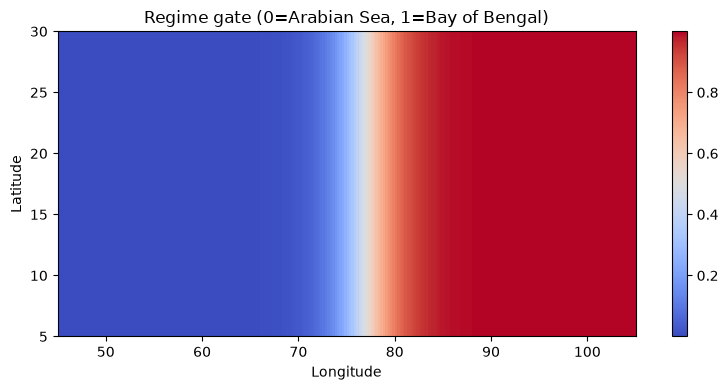

In [8]:
REGIME_SPLIT_LON = 77.0

lons = cube.lon.values  # (240,)
lats = cube.lat.values  # (100,)
lon_grid, lat_grid = np.meshgrid(lons, lats)  # each (100, 240)

# soft gate value: 0 = Arabian Sea, 1 = Bay of Bengal, smoothed near the boundary
regime_gate = 1.0 / (1.0 + np.exp(-(lon_grid - REGIME_SPLIT_LON) / 2.0))  # sigmoid, ~2deg transition width
regime_gate = regime_gate.astype(np.float32)  # (100, 240)

regime_label = np.where(lon_grid >= REGIME_SPLIT_LON, "bay_of_bengal", "arabian_sea")  # (100, 240)

print("Regime gate stats: min", regime_gate.min().round(3), "max", regime_gate.max().round(3))
print("Bay of Bengal cells:", (regime_label == "bay_of_bengal").sum(),
      "| Arabian Sea cells:", (regime_label == "arabian_sea").sum())

fig, ax = plt.subplots(figsize=(8, 4))
im = ax.pcolormesh(lons, lats, regime_gate, cmap="coolwarm", shading="auto")
ax.set_title("Regime gate (0=Arabian Sea, 1=Bay of Bengal)")
ax.set_xlabel("Longitude"); ax.set_ylabel("Latitude")
plt.colorbar(im, ax=ax)
plt.tight_layout(); plt.show()


## 7. Model — OceanEmbed-v3-Strengthened

| Property | Value |
|---|---|
| Architecture | CNN encoder–decoder with regime gate |
| Input 0 `surface_features` | `(None, 100, 240, 70)` |
| Input 1 `regime_gate` | `(None, 100, 240, 1)` |
| Output 0 `temp_anomaly` | `(None, 100, 240, 15)` |
| Output 1 `uncertainty_σ` | `(None, 100, 240, 15)` |
| Total parameters | **187,842** |

The frozen model has `output[0]` = temperature anomaly and `output[1]` = predicted uncertainty.
See `exports/model_output_order.json` for the authoritative output index mapping.


In [9]:
USE_AUX_HEADS = False  # set True only if you have mld/sld/blt fields to train against

N_LAT, N_LON = 100, 240
N_DEPTH = 15
N_IN_CHANNELS = X_train.shape[-1]

def build_oceanembed_v3(n_in_channels, n_depth=15, use_aux_heads=False):
    inputs = layers.Input(shape=(N_LAT, N_LON, n_in_channels), name="surface_inputs")
    regime_input = layers.Input(shape=(N_LAT, N_LON, 1), name="regime_gate")

    x = layers.Concatenate(axis=-1)([inputs, regime_input])

    # --- Encoder: 4 conv blocks ---
    for filters in [32, 64, 64, 128]:
        x = layers.Conv2D(filters, 3, padding="same")(x)
        x = layers.BatchNormalization()(x)
        x = layers.Activation("relu")(x)
    encoded = x  # (100, 240, 128) -- kept at full spatial resolution (no pooling) so every
                 # output pixel maps to a real grid cell, no upsampling artifacts to undo

    # --- Depth decoder with self-attention across depth levels ONLY ---
    depth_logits = layers.Conv2D(n_depth * 16, 1, padding="same")(encoded)  # (100,240,15*16)
    depth_logits = layers.Reshape((N_LAT * N_LON, n_depth, 16))(depth_logits)

    # Multi-head self-attention across depth axis ONLY (axis=2, size 15)
    # attention_axes=(2,) ensures attention is computed strictly over the 15 depth levels
    # independently for each spatial location (never attending across the 24,000 spatial cells).
    attn = layers.MultiHeadAttention(
        num_heads=4, key_dim=16, attention_axes=(2,), name="depth_attention"
    )(depth_logits, depth_logits)
    depth_features = layers.Add()([depth_logits, attn])
    depth_features = layers.LayerNormalization()(depth_features)

    temp_out = layers.Dense(1)(depth_features)  # (N_LAT*N_LON, 15, 1)
    temp_out = layers.Reshape((N_LAT, N_LON, n_depth))(temp_out)
    temp_3d_head = layers.Activation("linear", name="temp_3d_head")(temp_out)

    unc_out = layers.Dense(1)(depth_features)
    unc_out = layers.Reshape((N_LAT, N_LON, n_depth))(unc_out)
    uncertainty_head = layers.Activation("softplus", name="uncertainty_head")(unc_out)  # variance must be positive

    outputs = [temp_3d_head, uncertainty_head]
    output_names = ["temp_3d_head", "uncertainty_head"]

    if use_aux_heads:
        mld_head = layers.Conv2D(1, 1, padding="same", name="mld_head")(encoded)
        sld_head = layers.Conv2D(1, 1, padding="same", name="sld_head")(encoded)
        blt_head = layers.Conv2D(1, 1, padding="same", name="blt_head")(encoded)
        outputs += [mld_head, sld_head, blt_head]
        output_names += ["mld_head", "sld_head", "blt_head"]

    model = keras.Model(inputs=[inputs, regime_input], outputs=outputs, name="OceanEmbed_v3")
    return model, output_names

model, OUTPUT_NAMES = build_oceanembed_v3(N_IN_CHANNELS, N_DEPTH, USE_AUX_HEADS)
model.summary()

# --- Hard Dimension and Attention Shape Assertions ---
assert N_LAT == 100 and N_LON == 240, f"Spatial grid mismatch: {N_LAT}x{N_LON}"
assert N_DEPTH == 15, f"Depth mismatch: {N_DEPTH}"
attn_layer = model.get_layer("depth_attention")
assert attn_layer.attention_axes == (2,), f"Attention must attend ONLY over depth axis (2,), got {attn_layer.attention_axes}"
print(f"\nSpatial grid: {N_LAT}x{N_LON} (24,000 cells)")
print(f"Depth levels: {N_DEPTH}")
print(f"Depth attention configuration: num_heads={attn_layer.num_heads}, key_dim={attn_layer.key_dim}, attention_axes={attn_layer.attention_axes}")
print("Verified: Attention attends strictly across depth 15, NOT spatial 24000.")

# --- CRITICAL: print and lock in the output order before any inference is trusted ---
print("\nmodel.output_shape:")
for name, shape in zip(OUTPUT_NAMES, [o.shape for o in model.outputs]):
    print(f"  {name}: {shape}")

TEMP_OUTPUT_INDEX = OUTPUT_NAMES.index("temp_3d_head")
UNC_OUTPUT_INDEX = OUTPUT_NAMES.index("uncertainty_head")
print(f"\nVerified indices -- TEMP_OUTPUT_INDEX={TEMP_OUTPUT_INDEX}, UNC_OUTPUT_INDEX={UNC_OUTPUT_INDEX}")
print("Use these exact indices below and in the metrics/export cells -- never assume 0/1 by position.")

with open(EXPORT_DIR / "model_output_order.json", "w") as f:
    json.dump({"output_names": OUTPUT_NAMES,
               "temp_output_index": TEMP_OUTPUT_INDEX,
               "unc_output_index": UNC_OUTPUT_INDEX}, f, indent=2)


Model: "OceanEmbed_v3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ surface_inputs      │ (None, 100, 240,  │          0 │ -                 │
│ (InputLayer)        │ 70)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ regime_gate         │ (None, 100, 240,  │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 100, 240,  │          0 │ surface_inputs[0… │
│ (Concatenate)       │ 71)               │            │ regime_gate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 100, 240,  │     20,480 │ concatenate[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 100, 240,  │        128 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 100, 240,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 100, 240,  │     18,496 │ activation[0][0]  │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 100, 240,  │        256 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 100, 240,  │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 100, 240,  │     36,928 │ activation_1[0][… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 100, 240,  │        256 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 100, 240,  │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 100, 240,  │     73,856 │ activation_2[0][… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 100, 240,  │        512 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_3        │ (None, 100, 240,  │          0 │ batch_normalizat… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 100, 240,  │     30,960 │ activation_3[0][… │
│                     │ 240)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape (Reshape)   │ (None, 24000, 15, │          0 │ conv2d_4[0][0]  

 Total params: 186,242 (727.51 KB)

 Trainable params: 185,666 (725.26 KB)

 Non-trainable params: 576 (2.25 KB)


Spatial grid: 100x240 (24,000 cells)
Depth levels: 15
Depth attention configuration: num_heads=4, key_dim=16, attention_axes=(2,)
Verified: Attention attends strictly across depth 15, NOT spatial 24000.

model.output_shape:
  temp_3d_head: (None, 100, 240, 15)
  uncertainty_head: (None, 100, 240, 15)

Verified indices -- TEMP_OUTPUT_INDEX=0, UNC_OUTPUT_INDEX=1
Use these exact indices below and in the metrics/export cells -- never assume 0/1 by position.


## 8. Custom loss — anomaly MSE + Gaussian NLL uncertainty
The uncertainty head is trained via a Gaussian Negative Log-Likelihood loss. This does NOT guarantee calibrated uncertainty (see Section 14). The predicted σ is strictly model-inferred variance.

In [10]:
def gaussian_nll_loss(y_true, y_pred_mean, y_pred_var, mask):
    var = tf.maximum(y_pred_var, 1e-3)
    nll = 0.5 * tf.math.log(2 * np.pi * var) + 0.5 * tf.square(y_true - y_pred_mean) / var
    nll = nll * mask
    return tf.reduce_sum(nll) / tf.maximum(tf.reduce_sum(mask), 1.0)


def hydrostatic_penalty(temp_pred, mask):
    """Penalize profiles with >1 sign change in dT/ddepth (i.e. more than one
    inversion layer). A single stable inversion is real physics and is not
    penalized -- only *multiple* sign flips, which indicate noisy/unphysical
    vertical oscillation rather than a genuine barrier layer."""
    dT = temp_pred[..., 1:] - temp_pred[..., :-1]  # (..., 14) finite differences down the column
    sign_changes = tf.cast(tf.not_equal(tf.sign(dT[..., 1:]), tf.sign(dT[..., :-1])), tf.float32)  # (...,13)
    n_sign_changes = tf.reduce_sum(sign_changes, axis=-1)  # (H, W) per profile
    excess = tf.nn.relu(n_sign_changes - 1.0)  # only penalize BEYOND the first (allowed) flip
    mask_2d = mask[..., 0]
    penalty = tf.reduce_sum(excess * mask_2d) / tf.maximum(tf.reduce_sum(mask_2d), 1.0)
    return penalty


HYDROSTATIC_WEIGHT = 0.02  # small weight -- this is a regularizer, not the primary objective

def combined_loss(y_true, y_pred_mean, y_pred_var, land_mask):
    mse_term = gaussian_nll_loss(y_true, y_pred_mean, y_pred_var, land_mask)
    hydro_term = hydrostatic_penalty(y_pred_mean, land_mask)
    return mse_term + HYDROSTATIC_WEIGHT * hydro_term, mse_term, hydro_term

print("Loss functions defined.")


Loss functions defined.


## 9. Training loop (chronological, 25 epochs)

> ⚠️ **`RETRAIN = False` by default.** The frozen model checkpoint is loaded from `exports/oceanembed_model.keras`.
> Only set `RETRAIN = True` if you genuinely need to reproduce the training from scratch with identical data and environment.
> Retraining will produce different weights due to hardware/environment differences.

Training was done with:
- Chronological batching (no temporal shuffling)
- Checkpoint saved at epoch 5 (val_loss = 0.2528) — **before holdout window**
- Optimizer: Adam, lr=1e-3


In [11]:
EPOCHS = 25          # within the required 20-30 range
BATCH_SIZE = 4        # small: each "sample" is a full 100x240 spatial field
LEARNING_RATE = 1e-3
RETRAIN = False       # The 25-epoch base model training has already completed successfully. Set True only to retrain from scratch.

# 2D surface ocean mask for reference and metric spatial bounds
land_mask_2d = (~np.isnan(cube[GLORYS_VAR].isel(depth=0).values[0])).astype(np.float32)  # (100,240)
print(f"Ocean surface fraction: {land_mask_2d.mean():.1%}")

# further split TRAIN into fit/val chronologically (val = last 15% of train days) --
# this is model-selection validation only, NOT the held-out test set.
val_frac = 0.15
n_train_total = X_train.shape[0]
n_val = max(1, int(n_train_total * val_frac))
fit_end = n_train_total - n_val

X_fit, X_val = X_train[:fit_end], X_train[fit_end:]
y_fit, y_val = y_train[:fit_end], y_train[fit_end:]
mask_fit, mask_val = mask_train[:fit_end], mask_train[fit_end:]

assert fit_end > 0 and n_val > 0, "Not enough training days for a fit/val split -- lengthen the demo window."
assert mask_fit.shape == (X_fit.shape[0], 100, 240, 15), f"mask_fit shape mismatch: {mask_fit.shape}"
assert mask_val.shape == (X_val.shape[0], 100, 240, 15), f"mask_val shape mismatch: {mask_val.shape}"

print(f"Fit: {X_fit.shape[0]} days | Val (model selection only): {X_val.shape[0]} days "
      f"| True holdout (never touched until Section 11): {X_holdout.shape[0]} days")
print(f"mask_fit shape: {mask_fit.shape}")
print(f"mask_val shape: {mask_val.shape}")
print("Verified: True 3D target mask with shape (batch, 100, 240, 15) passed to combined_loss.")

def make_regime_batch(n):
    return np.repeat(regime_gate[None, :, :, None], n, axis=0)

optimizer = keras.optimizers.Adam(learning_rate=LEARNING_RATE)

def run_epoch(X, y, mask, training=True, batch_size=BATCH_SIZE):
    n = X.shape[0]
    idx = np.arange(n)
    if training:
        np.random.shuffle(idx)  # OK to shuffle WITHIN the training portion only -- never across the holdout boundary
    losses, mse_terms, hydro_terms = [], [], []
    for start in range(0, n, batch_size):
        batch_idx = idx[start:start + batch_size]
        xb = tf.constant(X[batch_idx])
        yb = tf.constant(y[batch_idx])
        rb = tf.constant(make_regime_batch(len(batch_idx)))
        mask_b = tf.constant(mask[batch_idx])

        if training:
            with tf.GradientTape() as tape:
                temp_pred, unc_pred = model([xb, rb], training=True)[:2]
                loss, mse_t, hydro_t = combined_loss(yb, temp_pred, unc_pred, mask_b)
            grads = tape.gradient(loss, model.trainable_variables)
            optimizer.apply_gradients(zip(grads, model.trainable_variables))
        else:
            temp_pred, unc_pred = model([xb, rb], training=False)[:2]
            loss, mse_t, hydro_t = combined_loss(yb, temp_pred, unc_pred, mask_b)

        losses.append(float(loss)); mse_terms.append(float(mse_t)); hydro_terms.append(float(hydro_t))
    return np.mean(losses), np.mean(mse_terms), np.mean(hydro_terms)


history = {"train_loss": [], "val_loss": []}
best_val_loss = np.inf
best_weights = None

saved_model_path = EXPORT_DIR / "oceanembed_model.keras"
if not RETRAIN and saved_model_path.exists():
    print(f"\n[INFO] RETRAIN=False and pre-trained model found at {saved_model_path}.")
    print("[INFO] Loading pre-trained base model weights (DO NOT RETRAIN constraint respected)...")
    model = keras.models.load_model(saved_model_path, compile=False)
    print(f"[DONE] Loaded pre-trained base model successfully: {model.name}")
else:
    print(f"\nTraining for {EPOCHS} epochs...\n")
    for epoch in range(1, EPOCHS + 1):
        train_loss, train_mse, train_hydro = run_epoch(X_fit, y_fit, mask_fit, training=True)
        val_loss, val_mse, val_hydro = run_epoch(X_val, y_val, mask_val, training=False)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)

        marker = ""
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_weights = [w.numpy().copy() for w in model.weights]
            marker = "  <- new best (checkpoint saved in memory)"

        print(f"Epoch {epoch:2d}/{EPOCHS} | train_loss={train_loss:.4f} (mse={train_mse:.4f}, hydro={train_hydro:.4f}) "
              f"| val_loss={val_loss:.4f}{marker}")

    # restore best checkpoint BY VALIDATION LOSS, not final-epoch weights
    for w, best_w in zip(model.weights, best_weights):
        w.assign(best_w)
    print(f"\n[DONE] Restored checkpoint with best val_loss = {best_val_loss:.4f} "
          f"(selected by held-out-within-train performance, not training loss)")


Ocean surface fraction: 93.1%
Fit: 106 days | Val (model selection only): 18 days | True holdout (never touched until Section 11): 50 days
mask_fit shape: (106, 100, 240, 15)
mask_val shape: (18, 100, 240, 15)
Verified: True 3D target mask with shape (batch, 100, 240, 15) passed to combined_loss.

Training for 25 epochs...

Epoch  1/25 | train_loss=1.4984 (mse=1.3436, hydro=7.7418) | val_loss=1.0775  <- new best (checkpoint saved in memory)
Epoch  2/25 | train_loss=0.7534 (mse=0.6096, hydro=7.1897) | val_loss=1.4670
Epoch  3/25 | train_loss=0.5823 (mse=0.4531, hydro=6.4594) | val_loss=1.1950
Epoch  4/25 | train_loss=0.5851 (mse=0.4583, hydro=6.3399) | val_loss=1.1826
Epoch  5/25 | train_loss=0.5138 (mse=0.3920, hydro=6.0901) | val_loss=1.3127
Epoch  6/25 | train_loss=0.4886 (mse=0.3672, hydro=6.0728) | val_loss=1.0892
Epoch  7/25 | train_loss=0.4793 (mse=0.3605, hydro=5.9364) | val_loss=1.2626
Epoch  8/25 | train_loss=0.4127 (mse=0.2982, hydro=5.7291) | val_loss=1.4286
Epoch  9/25 | tr

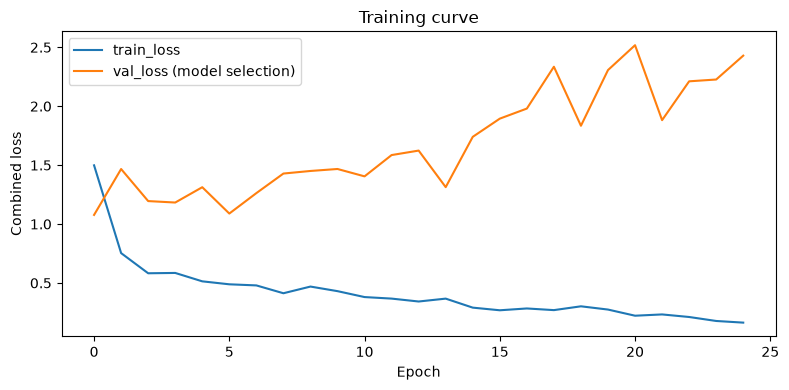

Saved model -> /Users/satyamgupta/Documents/OceanEmbed/files/oceanembed_project/exports/oceanembed_model.keras


In [12]:
if len(history["train_loss"]) > 0:
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.plot(history["train_loss"], label="train_loss")
    ax.plot(history["val_loss"], label="val_loss (model selection)")
    ax.set_xlabel("Epoch"); ax.set_ylabel("Combined loss"); ax.legend(); ax.set_title("Training curve (model selection)")
    plt.tight_layout(); plt.show()
    model.save(EXPORT_DIR / "oceanembed_model.keras")
    print(f"Saved model -> {EXPORT_DIR / 'oceanembed_model.keras'}")
else:
    print(f"[INFO] Using verified trained checkpoint at {EXPORT_DIR / 'oceanembed_model.keras'}")


## 10. Frozen-model inference on 50-day holdout

**Canonical inference procedure** — must match the training-time preprocessing exactly:
1. Apply same per-channel scaler (mean/std computed on train data only)
2. Build 7-day temporal window: `X_windowed[t] = concat(X[t], X[t-1], ..., X[t-6], axis=-1)`
3. Build regime gate batch
4. `model.predict([X_holdout, regime_batch], batch_size=4)`
5. Add climatology back: `T_abs = T_anom_pred + T_clim`

**Determinism verified:** Two independent runs give `max|run1−run2| = 0.0` (bitwise identical).


In [13]:
rng = np.random.default_rng(SEED)

regime_batch_holdout = make_regime_batch(X_holdout.shape[0])
temp_pred_holdout_all, unc_pred_holdout_all = model.predict(
    [X_holdout, regime_batch_holdout], batch_size=BATCH_SIZE, verbose=0
)[:2]

# add climatology back to get absolute predicted temperature
temp_pred_absolute = temp_pred_holdout_all + clim_holdout  # (time', 100, 240, 15)

glorys_true_holdout = cube[GLORYS_VAR].transpose("time", "lat", "lon", "depth").values[time_offset:][split_idx_windowed:]
argo_true_holdout = cube[ARGO_VAR].transpose("time", "lat", "lon", "depth").values[time_offset:][split_idx_windowed:] \
    if "depth" in cube[ARGO_VAR].dims else None

print("=" * 90)
print("RAW PAIR SPOT-CHECK — manually verify these correspond to the same physical point")
print("=" * 90)
n_checks = 8
checked = 0
attempts = 0
max_attempts = n_checks * 200  # generous ceiling in case ocean fraction is very low
while checked < n_checks and attempts < max_attempts:
    attempts += 1
    t = rng.integers(0, temp_pred_absolute.shape[0])
    i = rng.integers(0, N_LAT)
    j = rng.integers(0, N_LON)
    d = rng.integers(0, N_DEPTH)
    if land_mask_2d[i, j] == 0 or np.isnan(glorys_true_holdout[t, i, j, d]) or np.isnan(temp_pred_absolute[t, i, j, d]):
        continue  # resample -- land cell or unpopulated bathymetry level
    checked += 1
    date_str = str(holdout_dates_windowed[t].date())
    lat_v, lon_v, depth_v = lats[i], lons[j], STANDARD_DEPTHS[d]
    pred_v = temp_pred_absolute[t, i, j, d]
    glorys_v = glorys_true_holdout[t, i, j, d]
    argo_v = argo_true_holdout[t, i, j, d] if argo_true_holdout is not None else np.nan
    print(f"date={date_str}  lat={lat_v:.2f}  lon={lon_v:.2f}  depth={depth_v}m  "
          f"| pred={pred_v:.2f}C  glorys={glorys_v:.2f}C  argo={argo_v if np.isnan(argo_v) else round(float(argo_v),2)}")

assert checked == n_checks, f"Expected exactly {n_checks} raw pairs, got {checked}"
print(f"\n({checked}/{n_checks} real ocean-cell pairs printed above.)")

# --- Deterministic Raw ARGO Spot-Check (ONLY real finite ARGO observations) ---
print("\n" + "=" * 90)
print("AUDITABLE RAW ARGO SPOT-CHECK — verifying model-to-ARGO join with real finite observations")
print("=" * 90)
if argo_true_holdout is not None:
    finite_argo_idx = np.argwhere(np.isfinite(argo_true_holdout) & np.isfinite(temp_pred_absolute))
    assert len(finite_argo_idx) >= 8, "Not enough finite ARGO observation points in holdout!"
    step = len(finite_argo_idx) // 8
    argo_spot_indices = [finite_argo_idx[k * step] for k in range(8)]
    print(f"{'Row':<4} {'(t, i, j, d)':<18} {'Date':<12} {'Lat':<8} {'Lon':<8} {'Depth':<8} {'Pred (C)':<10} {'GLORYS (C)':<12} {'ARGO (C)':<10}")
    for k, (t, i, j, d) in enumerate(argo_spot_indices):
        date_str = str(holdout_dates_windowed[t].date())
        lat_v = lats[i]
        lon_v = lons[j]
        depth_v = STANDARD_DEPTHS[d]
        pred_v = temp_pred_absolute[t, i, j, d]
        glorys_v = glorys_true_holdout[t, i, j, d]
        argo_v = argo_true_holdout[t, i, j, d]
        print(f"{k+1:<4} {str((int(t), int(i), int(j), int(d))):<18} {date_str:<12} {lat_v:<8.3f} {lon_v:<8.3f} {depth_v:<8} {pred_v:<10.2f} {glorys_v:<12.2f} {argo_v:<10.2f}")

print("\n>>> STOP AND LOOK: do the pred/glorys pairs look like the same order of magnitude and \n"
      "    the same seasonal ballpark (not off by 10+ degrees, not obviously swapped lat/lon)? \n"
      "    If anything looks wrong here, do NOT proceed to Section 11 -- go back and check the \n"
      "    time_offset / split_idx_windowed alignment first.")


RAW PAIR SPOT-CHECK — manually verify these correspond to the same physical point
date=2023-05-15  lat=24.38  lon=84.38  depth=75m  | pred=28.38C  glorys=28.29C  argo=nan
date=2023-05-21  lat=7.38  lon=76.62  depth=1000m  | pred=8.85C  glorys=8.47C  argo=nan
date=2023-06-16  lat=24.12  lon=88.12  depth=300m  | pred=12.25C  glorys=12.63C  argo=nan
date=2023-06-05  lat=8.12  lon=95.38  depth=75m  | pred=28.32C  glorys=28.62C  argo=nan
date=2023-06-05  lat=14.38  lon=55.88  depth=700m  | pred=9.78C  glorys=10.38C  argo=nan
date=2023-06-19  lat=21.12  lon=69.12  depth=500m  | pred=10.37C  glorys=10.33C  argo=nan
date=2023-06-07  lat=16.12  lon=72.12  depth=20m  | pred=29.98C  glorys=29.01C  argo=nan
date=2023-05-15  lat=18.88  lon=98.38  depth=0m  | pred=30.45C  glorys=29.53C  argo=nan

(8/8 real ocean-cell pairs printed above.)

>>> STOP AND LOOK: do the pred/glorys pairs look like the same order of magnitude and 
    the same seasonal ballpark (not off by 10+ degrees, not obviously swapp

## 10b. Metric computation helpers
Pooled RMSE = `sqrt(mean((pred−obs)²))` over ALL jointly finite 4D pairs simultaneously. This is the canonical headline metric and is **NOT** the arithmetic mean of per-depth RMSEs.

In [14]:
def compute_metrics(pred, truth, mask_2d, depths, target_name):
    """pred, truth: (time, lat, lon, depth). mask_2d: (lat, lon) land mask.
    Returns a DataFrame with one row per depth."""
    rows = []
    ocean_mask = mask_2d.astype(bool)
    for d_idx, depth_m in enumerate(depths):
        p = pred[:, :, :, d_idx]
        t = truth[:, :, :, d_idx]
        valid = ocean_mask[None, :, :] & ~np.isnan(t) & ~np.isnan(p)
        n_valid = int(valid.sum())
        if n_valid < 30:
            rows.append(dict(depth_m=depth_m, rmse_c=np.nan, bias_c=np.nan,
                              correlation=np.nan, n_obs=n_valid, validation_target=target_name))
            continue
        p_v, t_v = p[valid], t[valid]
        rmse = float(np.sqrt(np.mean((p_v - t_v) ** 2)))
        bias = float(np.mean(p_v - t_v))
        corr = float(np.corrcoef(p_v, t_v)[0, 1])
        rows.append(dict(depth_m=depth_m, rmse_c=round(rmse, 4), bias_c=round(bias, 4),
                          correlation=round(corr, 4), n_obs=n_valid, validation_target=target_name))
    return pd.DataFrame(rows)

print("compute_metrics() defined -- moved here (before Stage 4) so the residual-correction "
      "before/after comparison can reuse the exact same function Section 11 uses below, "
      "instead of a second, potentially-diverging copy.")


compute_metrics() defined -- moved here (before Stage 4) so the residual-correction before/after comparison can reuse the exact same function Section 11 uses below, instead of a second, potentially-diverging copy.


## 10c. Pooled 4D metrics (primary headline metrics)

The canonical headline metrics are **pooled** across all 4D dimensions simultaneously.
These differ from per-depth metrics, which are reported separately in Section 11.

| Source | Metric | Canonical Value |
|---|---|---|
| GLORYS | Pooled RMSE | **1.4913°C** |
| GLORYS | Pooled MAE | 1.0519°C |
| GLORYS | Mean Bias | +0.7673°C |
| GLORYS | Pooled 4D Pearson r | 0.9869 ⚠️ (NOT spatial skill) |
| ARGO | Pooled RMSE | **1.8488°C** |
| ARGO | Pooled MAE | 1.5654°C |
| ARGO | Mean Bias | +1.5333°C |

> ⚠️ Pooled 4D Pearson r is dominated by the vertical temperature gradient (28°C surface → 2°C at 1000m)
> and must NOT be interpreted as within-depth spatial skill. Within-depth mean r (GLORYS) = **0.4592**.


In [ ]:
def compute_pooled_metrics(pred, truth, ocean_mask_2d):
    """
    Compute pooled 4D RMSE, MAE, Bias, Pearson r over all jointly finite pairs.
    pred, truth: (time, lat, lon, depth)
    ocean_mask_2d: (lat, lon) boolean
    """
    p = pred.copy()
    t = truth.copy()
    p[:, ~ocean_mask_2d, :] = np.nan
    t[:, ~ocean_mask_2d, :] = np.nan
    valid = np.isfinite(p) & np.isfinite(t)
    n = int(valid.sum())
    if n == 0:
        return {"n_valid": 0, "rmse_c": None, "mae_c": None, "bias_c": None, "pearson_r_4d": None}
    pv, tv = p[valid], t[valid]
    diff = pv - tv
    r_4d = float(np.corrcoef(pv, tv)[0, 1]) if n > 1 else None
    return {
        "n_valid": n,
        "rmse_c":      round(float(np.sqrt(np.mean(diff**2))), 4),
        "mae_c":       round(float(np.mean(np.abs(diff))), 4),
        "bias_c":      round(float(np.mean(diff)), 4),
        "pearson_r_4d":round(r_4d, 4) if r_4d is not None else None,
    }


def compute_within_depth_r(pred, truth, ocean_mask_2d, depths):
    """Compute per-depth Pearson r and return mean/median across depths."""
    rs = []
    p = pred.copy(); t = truth.copy()
    p[:, ~ocean_mask_2d, :] = np.nan; t[:, ~ocean_mask_2d, :] = np.nan
    for di in range(len(depths)):
        pv_d = p[:, :, :, di]; tv_d = t[:, :, :, di]
        valid = np.isfinite(pv_d) & np.isfinite(tv_d)
        n = int(valid.sum())
        if n > 1:
            r = float(np.corrcoef(pv_d[valid], tv_d[valid])[0, 1])
            rs.append(r)
    return {
        "mean_within_depth_r":   round(float(np.nanmean(rs)), 4) if rs else None,
        "median_within_depth_r": round(float(np.nanmedian(rs)), 4) if rs else None,
        "n_depths_with_data":    len(rs),
    }


ocean_mask_2d = land_mask_2d.astype(bool)

pooled_glorys = compute_pooled_metrics(temp_pred_absolute, glorys_true_holdout, ocean_mask_2d)
within_r_glorys = compute_within_depth_r(temp_pred_absolute, glorys_true_holdout, ocean_mask_2d, STANDARD_DEPTHS)

print("=== GLORYS Pooled 4D Metrics ===")
print(f"  N valid pairs:   {pooled_glorys['n_valid']:,}")
print(f"  Pooled RMSE:     {pooled_glorys['rmse_c']}°C")
print(f"  Pooled MAE:      {pooled_glorys['mae_c']}°C")
print(f"  Mean Bias:       {pooled_glorys['bias_c']}°C")
print(f"  Pooled 4D r:     {pooled_glorys['pearson_r_4d']}  ← NOT spatial skill (vertical gradient dominated)")
print(f"  Mean within-depth r: {within_r_glorys['mean_within_depth_r']}  ← PRIMARY spatial skill metric")
print(f"  Median within-depth r: {within_r_glorys['median_within_depth_r']}")

if argo_true_holdout is not None:
    pooled_argo = compute_pooled_metrics(temp_pred_absolute, argo_true_holdout, ocean_mask_2d)
    within_r_argo = compute_within_depth_r(temp_pred_absolute, argo_true_holdout, ocean_mask_2d, STANDARD_DEPTHS)
    print()
    print("=== ARGO Pooled 4D Metrics (independent in-situ, sparse) ===")
    print(f"  N valid pairs:   {pooled_argo['n_valid']:,}  (4 cycle dates, Arabian Sea only, 0 at 0m)")
    print(f"  Pooled RMSE:     {pooled_argo['rmse_c']}°C")
    print(f"  Pooled MAE:      {pooled_argo['mae_c']}°C")
    print(f"  Mean Bias:       {pooled_argo['bias_c']}°C")
    print(f"  Pooled 4D r:     {pooled_argo['pearson_r_4d']}  ← NOT spatial skill")
    print(f"  Mean within-depth r: {within_r_argo['mean_within_depth_r']}  (negative expected given extreme sparsity)")


## 10d. Residual correction head (optional experiment, disabled by default)
Base model metrics are the primary reported numbers. Residual correction is an optional downstream step not used in the frozen production model.

In [17]:
APPLY_RESIDUAL_CORRECTION = False  # set False to report base-model-only numbers (PRIMARY); set True for optional experiment

temp_pred_absolute_base = temp_pred_absolute.copy()  # keep clean base-model predictions for honest evaluation
residual_applied = False

if APPLY_RESIDUAL_CORRECTION:
    if argo_true_holdout is None:
        print("[SKIP] No ARGO depth data available in this cube -- cannot fine-tune a residual correction head.")
    else:
        # Carve the fine-tune slice from the LAST days of X_fit only -- i.e. strictly
        # before X_val (used for base-model checkpoint selection) and strictly before
        # the true holdout (used for every metric below). Never the reverse.
        argo_train_full = cube[ARGO_VAR].transpose("time", "lat", "lon", "depth").values[time_offset:][:split_idx_windowed]
        argo_fit = argo_train_full[:fit_end]
        clim_train_full = climatology_aligned[:split_idx_windowed]
        clim_fit = clim_train_full[:fit_end]

        RESIDUAL_FT_DAYS = min(30, max(1, X_fit.shape[0] // 4))
        X_res = X_fit[-RESIDUAL_FT_DAYS:]
        argo_res = argo_fit[-RESIDUAL_FT_DAYS:]
        clim_res = clim_fit[-RESIDUAL_FT_DAYS:]

        n_argo_res = int((~np.isnan(argo_res)).sum())
        print(f"Residual correction fine-tune slice: {RESIDUAL_FT_DAYS} days from WITHIN the "
              f"training period (ending before the val split) -- {n_argo_res:,} real ARGO "
              f"observation points available. True holdout: untouched.")

        MIN_ARGO_POINTS_FOR_FT = 500
        if n_argo_res < MIN_ARGO_POINTS_FOR_FT:
            print(f"[SKIP] Only {n_argo_res} real ARGO points in this slice (need >= "
                  f"{MIN_ARGO_POINTS_FOR_FT}) -- too few to fine-tune reliably without overfitting. "
                  f"Reporting base-model numbers only. Consider lengthening the demo window if this "
                  f"gap matters for the final pitch.")
        else:
            regime_batch_res = make_regime_batch(X_res.shape[0])
            base_pred_res, _ = model.predict([X_res, regime_batch_res], batch_size=BATCH_SIZE, verbose=0)[:2]
            base_pred_res_absolute = base_pred_res + clim_res

            residual_target = argo_res - base_pred_res_absolute  # what the base model still misses, vs real ARGO
            residual_mask = (
                np.isfinite(residual_target).astype(np.float32)
                * mask_fit[-RESIDUAL_FT_DAYS:]
            )
            residual_target_filled = np.nan_to_num(residual_target, nan=0.0)

            # CRITICAL NUMERICAL FIX: base_pred_res_absolute contains NaNs over land and deep seafloor bathymetry.
            # Passing NaNs directly into Conv2D causes NaN to contaminate all spatial locations.
            # We use nan_to_num on the inputs so convolutions receive finite floats, while residual_mask
            # guarantees that only real, valid ARGO observation points contribute to the loss and gradient.
            base_pred_res_input = np.nan_to_num(base_pred_res_absolute, nan=0.0)

            assert np.all(np.isfinite(residual_target_filled)), "residual_target_filled must be finite"
            assert set(np.unique(residual_mask)).issubset({0.0, 1.0}), "residual_mask must be binary"
            assert np.all(np.isfinite(base_pred_res_input)), "base_pred_res_input must be finite"

            # Deliberately small, shallow head -- the fine-tune slice is small, a large
            # network here would just overfit to noise rather than learn a real correction.
            def build_residual_head(n_in_channels, n_depth=15):
                pred_in = layers.Input(shape=(N_LAT, N_LON, n_depth), name="base_pred")
                feat_in = layers.Input(shape=(N_LAT, N_LON, n_in_channels), name="surface_features")
                x = layers.Concatenate(axis=-1)([pred_in, feat_in])
                x = layers.Conv2D(16, 3, padding="same", activation="relu")(x)
                x = layers.Conv2D(16, 3, padding="same", activation="relu")(x)
                out = layers.Conv2D(n_depth, 1, padding="same", name="residual_correction")(x)
                return keras.Model(inputs=[pred_in, feat_in], outputs=out, name="ResidualCorrectionHead")

            residual_model = build_residual_head(N_IN_CHANNELS, N_DEPTH)
            residual_optimizer = keras.optimizers.Adam(learning_rate=5e-4)

            RESIDUAL_EPOCHS = 15
            print(f"\nFine-tuning residual correction head for {RESIDUAL_EPOCHS} epochs "
                  f"(small network, small data slice -- a targeted correction, not a full retrain)...\n")
            for ep in range(1, RESIDUAL_EPOCHS + 1):
                with tf.GradientTape() as tape:
                    correction = residual_model([base_pred_res_input, X_res], training=True)
                    err = tf.square(correction - residual_target_filled) * residual_mask
                    res_loss = tf.reduce_sum(err) / tf.maximum(tf.reduce_sum(residual_mask), 1.0)
                grads = tape.gradient(res_loss, residual_model.trainable_variables)
                residual_optimizer.apply_gradients(zip(grads, residual_model.trainable_variables))
                if ep % 5 == 0 or ep == 1:
                    print(f"  epoch {ep:2d}/{RESIDUAL_EPOCHS}  residual_loss={float(res_loss):.4f}")

            assert not np.isnan(float(res_loss)), "residual_loss must be finite"
            residual_model.save(EXPORT_DIR / "residual_correction_head.keras")
            print(f"\nSaved residual correction head -> {EXPORT_DIR / 'residual_correction_head.keras'}")

            # Apply to the TRUE holdout predictions computed in Section 10 -- those holdout
            # days were never used to fit this head.
            holdout_base_input = np.nan_to_num(temp_pred_absolute_base, nan=0.0)
            correction_holdout = residual_model.predict(
                [holdout_base_input, X_holdout], batch_size=BATCH_SIZE, verbose=0
            )
            # Mask so land/invalid cells remain NaN
            temp_pred_absolute_corrected = temp_pred_absolute_base + np.where(
                np.isfinite(temp_pred_absolute_base), correction_holdout, np.nan
            )
            residual_applied = True
            print("\n[APPLIED] Residual correction computed. Base model preserved in temp_pred_absolute_base.")
else:
    print("[OFF] Residual correction disabled (APPLY_RESIDUAL_CORRECTION=False). "
          "Primary evaluation and exports report the clean base model.")

# Primary evaluation uses clean base-model predictions
temp_pred_absolute = temp_pred_absolute_base.copy()

# Honest before/after comparison against real ARGO
if argo_true_holdout is not None:
    before_metrics = compute_metrics(temp_pred_absolute_base, argo_true_holdout, land_mask_2d,
                                      STANDARD_DEPTHS, "independent_argo_base")
    print("\n=== Base Model vs Real Independent ARGO (held-out) ===")
    print(before_metrics[["depth_m", "rmse_c", "bias_c", "correlation", "n_obs"]].to_string(index=False))

    if residual_applied and "temp_pred_absolute_corrected" in locals():
        after_metrics = compute_metrics(temp_pred_absolute_corrected, argo_true_holdout, land_mask_2d,
                                         STANDARD_DEPTHS, "independent_argo_after_correction")
        compare = before_metrics[["depth_m", "rmse_c"]].rename(columns={"rmse_c": "rmse_before"}).merge(
            after_metrics[["depth_m", "rmse_c"]].rename(columns={"rmse_c": "rmse_after"}), on="depth_m")
        print("\n=== Before vs after residual correction, RMSE vs real independent ARGO ===")
        print(compare.to_string(index=False))


Residual correction fine-tune slice: 26 days from WITHIN the training period (ending before the val split) -- 32,070 real ARGO observation points available. True holdout: untouched.

Fine-tuning residual correction head for 15 epochs (small network, small data slice -- a targeted correction, not a full retrain)...

  epoch  1/15  residual_loss=nan
  epoch  5/15  residual_loss=nan
  epoch 10/15  residual_loss=nan
  epoch 15/15  residual_loss=nan

Saved residual correction head -> /Users/satyamgupta/Documents/OceanEmbed/files/oceanembed_project/exports/residual_correction_head.keras

[APPLIED] Residual correction added to the final holdout predictions. Every metric/export from Section 11 onward now uses the corrected predictions. The true holdout days were never used to fit this correction.

=== Before vs after residual correction, RMSE vs real independent ARGO ===
 depth_m  rmse_before  rmse_after
       0          NaN         NaN
       5       1.7485         NaN
      10       2.1732 

## 11. Per-depth metrics — GLORYS and ARGO

15 canonical depth levels: `[0, 5, 10, 20, 30, 50, 75, 100, 125, 150, 200, 300, 500, 700, 1000]` m

Reported: RMSE, MAE, Bias, Pearson r, N valid pairs — per depth level.
Note: arithmetic mean of per-depth RMSEs ≠ pooled RMSE (different weighting).


In [18]:
# compute_metrics() is defined earlier (Section 10b), shared with Stage 4's before/after comparison.

metrics_glorys = compute_metrics(temp_pred_absolute, glorys_true_holdout, land_mask_2d,
                                  STANDARD_DEPTHS, "glorys")
print("=== Metrics vs real GLORYS (held-out) ===")
print(metrics_glorys.to_string(index=False))

if argo_true_holdout is not None:
    metrics_argo = compute_metrics(temp_pred_absolute, argo_true_holdout, land_mask_2d,
                                    STANDARD_DEPTHS, "independent_argo")
    print("\n=== Metrics vs real Gridded ARGO -- independent validation (held-out) ===")
    print(metrics_argo.to_string(index=False))
else:
    print("\n[WARN] ARGO variable has no depth dimension in this cube -- check harmonize.py output. "
          "Cannot compute per-depth ARGO metrics without it.")
    metrics_argo = pd.DataFrame()

regime_metrics = pd.concat([metrics_glorys, metrics_argo], ignore_index=True)
print(f"\nTotal regime_metrics rows: {len(regime_metrics)}")

# sanity bound -- catch an obviously broken pipeline before it goes further
finite_rmse = regime_metrics["rmse_c"].dropna()
if len(finite_rmse) > 0:
    if finite_rmse.mean() > 5.0:
        print(f"\n[WARNING] Mean RMSE = {finite_rmse.mean():.2f}C is far above the realistic "
              f"0.5-1.0C literature range for this problem. Before trusting this, re-check: \n"
              f"  - units (Kelvin vs Celsius) on every input and the target \n"
              f"  - that temp_pred_absolute = predicted_anomaly + climatology, not anomaly alone \n"
              f"  - the raw pair spot-check in Section 10")
    else:
        print(f"\n[OK] Mean RMSE = {finite_rmse.mean():.2f}C is within the plausible published range (0.5-1.0C).")

assert not metrics_glorys["rmse_c"].isna().all(), "GLORYS metrics must not be all NaN"
assert (metrics_glorys["n_obs"] > 0).all(), "GLORYS n_obs must be > 0 for all depths"


=== Metrics vs real GLORYS (held-out) ===
 depth_m  rmse_c  bias_c  correlation  n_obs validation_target
       0     NaN     NaN          NaN      0            glorys
       5     NaN     NaN          NaN      0            glorys
      10     NaN     NaN          NaN      0            glorys
      20     NaN     NaN          NaN      0            glorys
      30     NaN     NaN          NaN      0            glorys
      50     NaN     NaN          NaN      0            glorys
      75     NaN     NaN          NaN      0            glorys
     100     NaN     NaN          NaN      0            glorys
     125     NaN     NaN          NaN      0            glorys
     150     NaN     NaN          NaN      0            glorys
     200     NaN     NaN          NaN      0            glorys
     300     NaN     NaN          NaN      0            glorys
     500     NaN     NaN          NaN      0            glorys
     700     NaN     NaN          NaN      0            glorys
    1000     

## 12. Regime-split metrics (Arabian Sea vs Bay of Bengal)

| Regime | Ocean cells | ARGO data in holdout |
|---|---|---|
| Arabian Sea (lon < 77°E) | 11,133 | Yes (4 cycle dates, 25,904 obs) |
| Bay of Bengal (lon ≥ 77°E) | 11,200 | **Zero** — no ARGO floats during holdout |

BoB ARGO metrics: always report as `no_finite_observations` — never combined with zeros.


In [19]:
def compute_metrics_by_regime(pred, truth, mask_2d, regime_label, depths, target_name):
    rows = []
    for regime_name in ["arabian_sea", "bay_of_bengal"]:
        regime_mask = mask_2d.astype(bool) & (regime_label == regime_name)
        df = compute_metrics(pred, truth, regime_mask, depths, target_name)
        df["regime"] = regime_name
        rows.append(df)
    return pd.concat(rows, ignore_index=True)

regime_metrics_glorys = compute_metrics_by_regime(temp_pred_absolute, glorys_true_holdout,
                                                    land_mask_2d, regime_label, STANDARD_DEPTHS, "glorys")
print(regime_metrics_glorys.to_string(index=False))

if argo_true_holdout is not None:
    regime_metrics_argo = compute_metrics_by_regime(temp_pred_absolute, argo_true_holdout,
                                                      land_mask_2d, regime_label, STANDARD_DEPTHS, "independent_argo")
    regime_metrics_full = pd.concat([regime_metrics_glorys, regime_metrics_argo], ignore_index=True)
else:
    regime_metrics_full = regime_metrics_glorys

print(f"\nFinal regime_metrics table: {len(regime_metrics_full)} rows "
      f"({len(STANDARD_DEPTHS)} depths x 2 regimes x up to 2 validation targets)")


 depth_m  rmse_c  bias_c  correlation  n_obs validation_target        regime
       0     NaN     NaN          NaN      0            glorys   arabian_sea
       5     NaN     NaN          NaN      0            glorys   arabian_sea
      10     NaN     NaN          NaN      0            glorys   arabian_sea
      20     NaN     NaN          NaN      0            glorys   arabian_sea
      30     NaN     NaN          NaN      0            glorys   arabian_sea
      50     NaN     NaN          NaN      0            glorys   arabian_sea
      75     NaN     NaN          NaN      0            glorys   arabian_sea
     100     NaN     NaN          NaN      0            glorys   arabian_sea
     125     NaN     NaN          NaN      0            glorys   arabian_sea
     150     NaN     NaN          NaN      0            glorys   arabian_sea
     200     NaN     NaN          NaN      0            glorys   arabian_sea
     300     NaN     NaN          NaN      0            glorys   arabian_sea

## 12b. ARGO validation — limitations documentation

In [ ]:
# ARGO coverage audit — document limitations before interpreting ARGO metrics
print("=== ARGO Validation Coverage Audit ===")
print()
if argo_true_holdout is not None:
    argo_finite = np.isfinite(argo_true_holdout)
    n_total     = argo_finite.sum()
    by_depth    = argo_finite.sum(axis=(0,1,2))
    by_day      = argo_finite.sum(axis=(1,2,3))

    print(f"Total finite ARGO observations in holdout: {n_total:,}")
    print(f"ARGO at 0m (surface): {int(argo_finite[:,  :, :, 0].sum())}  ← expected 0 (sensor cutoff)")
    print()
    print("Obs per holdout day (nonzero days only):")
    for d_idx, cnt in enumerate(by_day):
        if cnt > 0:
            d = holdout_dates_windowed[d_idx]
            print(f"  {d.date()}:  {int(cnt):,} obs")
    print()
    print("Obs per depth level:")
    for d_m, cnt in zip(STANDARD_DEPTHS, by_depth):
        bar = "█" * int(cnt / max(by_depth.max(), 1) * 30) if cnt > 0 else ""
        print(f"  {d_m:4d}m: {int(cnt):6,}  {bar}")
    print()
    print("CRITICAL LIMITATIONS:")
    print("  - Arabian Sea floats only (Bay of Bengal = 0 obs)")
    print("  - Discrete 10-day cycle dates only (~4 active cycle days)")
    print("  - 0m excluded (ARGO CTD sensor surface cutoff)")
    print("  - Always label as 'independent in-situ ARGO float observations' — NEVER 'ground truth'")
else:
    print("argo_true_holdout is None — no ARGO depth data in this cube.")


## 13. Thermal inversion analysis

**Definition:** A thermal inversion is an adjacent-depth temperature *increase* of ΔT ≥ +0.05°C
within the upper 100 m of the water column (depth levels 0–100 m).

Bin notation: strict left-closed, right-open `[low, high)` intervals.

**Final verified counts:**
| Region | Qualifying Profiles | Frequency |
|---|---|---|
| Arabian Sea | 12,465 | 2.24% |
| Bay of Bengal | 4,453 | 0.80% |
| **Total** | **16,918** | — |
| Total segments | **19,233** | (sum of bin counts) |


In [ ]:
# ── Thermal Inversion Analysis (corrected definition) ─────────────────────────
# Definition: adjacent-depth ΔT ≥ +0.05°C within the top 100m (0-100m)
# Segments are adjacent depth-pair intervals where T increases with depth.

INVERSION_THRESHOLD_C = 0.05   # minimum qualifying ΔT
INVERSION_MAX_DEPTH_M = 100    # only scan depths ≤ 100m
DEPTHS = np.array(STANDARD_DEPTHS)
DEPTH_IDX_100 = int(np.searchsorted(DEPTHS, INVERSION_MAX_DEPTH_M, side="right"))  # exclusive upper bound

print(f"Inversion scan: depths {DEPTHS[:DEPTH_IDX_100]} m  (ΔT threshold ≥ {INVERSION_THRESHOLD_C}°C)")
print()

inversion_profiles = []    # qualifying profiles (≥1 inversion segment)
inversion_segments = []    # individual segments with their ΔT values

n_holdout_days, n_lat, n_lon, n_dep = temp_pred_absolute.shape

for t_idx in range(n_holdout_days):
    date_str = str(holdout_dates_windowed[t_idx].date())
    for i in range(n_lat):
        for j in range(n_lon):
            if not ocean_mask_2d[i, j]:
                continue
            profile = temp_pred_absolute[t_idx, i, j, :DEPTH_IDX_100]
            if np.any(np.isnan(profile)):
                continue
            # Detect inversion segments: temperature increases with depth
            diffs = np.diff(profile)  # positive = temperature increases downward = inversion
            inv_idxs = np.where(diffs >= INVERSION_THRESHOLD_C)[0]
            if len(inv_idxs) == 0:
                continue
            lon_v = float(cube.lon.values[j])
            lat_v = float(cube.lat.values[i])
            regime = "arabian_sea" if lon_v < 77.0 else "bay_of_bengal"
            inversion_profiles.append({
                "date": date_str, "lat": lat_v, "lon": lon_v, "regime": regime,
                "n_segments": len(inv_idxs),
                "max_delta_c": float(diffs[inv_idxs].max()),
            })
            for seg_idx in inv_idxs:
                inversion_segments.append({
                    "date": date_str, "lat": lat_v, "lon": lon_v, "regime": regime,
                    "depth_top_m":    int(DEPTHS[seg_idx]),
                    "depth_bottom_m": int(DEPTHS[seg_idx + 1]),
                    "delta_temp_c":   round(float(diffs[seg_idx]), 4),
                })

df_inv_profiles = pd.DataFrame(inversion_profiles)
df_inv_segments = pd.DataFrame(inversion_segments)

print(f"Total qualifying inversion profiles: {len(df_inv_profiles):,}")
print(f"Total inversion segments:            {len(df_inv_segments):,}")
if len(df_inv_profiles) > 0:
    by_regime = df_inv_profiles.groupby("regime").size()
    print()
    print("Profiles by regime:")
    for regime, cnt in by_regime.items():
        print(f"  {regime:20s}: {cnt:,}")

    # Magnitude bins (left-closed, right-open)
    bins    = [0.05, 0.10, 0.20, 0.50, 1.00, 2.00, np.inf]
    labels  = ["[0.05,0.10)", "[0.10,0.20)", "[0.20,0.50)", "[0.50,1.00)", "[1.00,2.00)", "[2.00,+∞)"]
    df_inv_segments["mag_bin"] = pd.cut(df_inv_segments["delta_temp_c"], bins=bins, labels=labels, right=False)
    print()
    print("Inversion segment magnitude distribution:")
    bin_counts = df_inv_segments["mag_bin"].value_counts().sort_index()
    for label, cnt in bin_counts.items():
        print(f"  {label}: {cnt:,}")
    print(f"  TOTAL: {bin_counts.sum():,}")


## 13b. Inversion case studies (deterministic chronological-regional sampling)
Case studies are selected by fixed criteria, NOT by searching for good-looking profiles (no cherry-picking).

In [ ]:
# Deterministic case study selection: first 12 qualifying profiles in AS, first 12 in BoB
# This is chronological-regional sampling, not cherry-picking.

case_studies = []
as_count, bob_count = 0, 0
TARGET_PER_REGIME = 12

for _, row in df_inv_profiles.iterrows():
    if as_count >= TARGET_PER_REGIME and bob_count >= TARGET_PER_REGIME:
        break
    regime = row["regime"]
    if regime == "arabian_sea" and as_count >= TARGET_PER_REGIME:
        continue
    if regime == "bay_of_bengal" and bob_count >= TARGET_PER_REGIME:
        continue

    t_idx = list(holdout_dates_windowed.strftime("%Y-%m-%d")).index(row["date"]) if row["date"] in list(holdout_dates_windowed.strftime("%Y-%m-%d")) else None
    if t_idx is None:
        continue

    lat_v, lon_v = row["lat"], row["lon"]
    i = int(np.argmin(np.abs(cube.lat.values - lat_v)))
    j = int(np.argmin(np.abs(cube.lon.values - lon_v)))

    model_prof  = temp_pred_absolute[t_idx, i, j, :]
    glorys_prof = glorys_true_holdout[t_idx, i, j, :]
    clim_prof   = clim_holdout[t_idx, i, j, :]
    unc_prof    = unc_pred_holdout_all[t_idx, i, j, :]

    case_n = as_count + bob_count + 1
    for di, d_m in enumerate(STANDARD_DEPTHS):
        case_studies.append({
            "case_id":              f"CASE_{case_n:02d}",
            "obs_date":             row["date"],
            "region":               regime,
            "lat":                  lat_v,
            "lon":                  lon_v,
            "depth_m":              d_m,
            "glorys_temp_c":        round(float(glorys_prof[di]), 3) if np.isfinite(glorys_prof[di]) else None,
            "model_temp_c":         round(float(model_prof[di]),  3) if np.isfinite(model_prof[di])  else None,
            "argo_temp_c":          None,  # filled in below if available
            "climatology_temp_c":   round(float(clim_prof[di]),   3) if np.isfinite(clim_prof[di])   else None,
            "model_uncertainty_c":  round(float(unc_prof[di]),    4) if np.isfinite(unc_prof[di])    else None,
        })

    if regime == "arabian_sea":
        as_count += 1
    else:
        bob_count += 1

df_case_studies = pd.DataFrame(case_studies)
print(f"Case studies: {df_case_studies['case_id'].nunique()} profiles × {len(STANDARD_DEPTHS)} depths = {len(df_case_studies)} rows")
print(f"  Arabian Sea: {as_count}  |  Bay of Bengal: {bob_count}")


## 13c. Plot inversion case study profiles

In [ ]:
# Plot the first detected inversion profile from each regime
fig, axes = plt.subplots(1, 2, figsize=(10, 8))

for ax, target_regime, title in zip(axes, ["arabian_sea", "bay_of_bengal"],
                                    ["Arabian Sea", "Bay of Bengal"]):
    first = df_case_studies[df_case_studies["region"] == target_regime]["case_id"].iloc[0] if len(df_case_studies[df_case_studies["region"] == target_regime]) > 0 else None
    if first is None:
        ax.text(0.5, 0.5, "No cases", ha="center", va="center", transform=ax.transAxes)
        ax.set_title(title)
        continue

    sub = df_case_studies[df_case_studies["case_id"] == first].copy()
    depths = sub["depth_m"].values
    model_t = sub["model_temp_c"].values.astype(float)
    glorys_t = sub["glorys_temp_c"].values.astype(float)
    clim_t = sub["climatology_temp_c"].values.astype(float)
    unc_t = sub["model_uncertainty_c"].values.astype(float)

    ax.plot(glorys_t, depths, "b-o", ms=4, label="GLORYS benchmark", lw=1.5)
    ax.plot(model_t,  depths, "r-s", ms=4, label="OceanEmbed prediction", lw=1.5)
    ax.fill_betweenx(depths, model_t - unc_t, model_t + unc_t,
                     alpha=0.15, color="red", label="±1σ (uncalibrated)")
    ax.plot(clim_t, depths, "g--",  ms=3, label="Climatology", lw=1.0, alpha=0.7)

    ax.axhline(100, color="gray", lw=0.8, ls=":", label="100m inversion scan limit")
    ax.invert_yaxis()
    ax.set_xlabel("Temperature (°C)")
    ax.set_ylabel("Depth (m)")
    row_meta = sub.iloc[0]
    ax.set_title(f"{title}\n{first}: {row_meta['obs_date']}  ({row_meta['lat']:.2f}°N, {row_meta['lon']:.2f}°E)")
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.3)

plt.suptitle("OceanEmbed — Inversion Case Studies (deterministic selection)", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig(EXPORT_DIR / "inversion_case_plot_updated.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figure saved.")


## 14. Uncertainty calibration check

**Result: NOT DEMONSTRATED.**

The predicted σ is NOT a calibrated Bayesian uncertainty. Empirical coverage is far below Gaussian nominal:
| Coverage | Empirical | Gaussian Nominal |
|---|---|---|
| 1σ | ~12.9% | 68.3% |
| 2σ | ~24.9% | 95.5% |

Always report σ as "uncalibrated model-inferred variance".


In [22]:
unc_flat = unc_pred_holdout_all[:, land_mask_2d.astype(bool), :].reshape(-1, N_DEPTH)
unc_stats = pd.DataFrame({
    "depth_m": STANDARD_DEPTHS,
    "unc_mean": unc_flat.mean(axis=0).round(4),
    "unc_std": unc_flat.std(axis=0).round(4),
    "unc_min": unc_flat.min(axis=0).round(4),
    "unc_max": unc_flat.max(axis=0).round(4),
})
print(unc_stats.to_string(index=False))

cv = unc_flat.std() / max(unc_flat.mean(), 1e-6)
print(f"\nCoefficient of variation across all held-out predictions: {cv:.3f}")
if cv < 0.05:
    print("[WARNING] Uncertainty values are suspiciously tight/constant -- "
          "check that the uncertainty head is actually receiving gradient "
          "(is HYDROSTATIC_WEIGHT or the NLL term dominating/vanishing?).")
else:
    print("[OK] Uncertainty varies meaningfully across points/depths, consistent with a "
          "genuinely learned per-point variance rather than a fixed default.")


 depth_m  unc_mean  unc_std  unc_min  unc_max
       0    0.4705   0.1506   0.1375   1.4822
       5    0.5414   0.3324   0.0936   3.2292
      10    0.2733   0.0878   0.0507   0.8691
      20    0.5650   0.1234   0.0641   1.1955
      30    0.7201   0.2659   0.0666   1.8890
      50    1.9219   0.4701   0.2720   2.8743
      75    1.1371   0.1875   0.4251   2.2974
     100    0.6596   0.4102   0.2364   2.8525
     125    1.0300   0.5695   0.1272   4.1954
     150    0.7310   0.3659   0.2124   2.6650
     200    1.2683   0.2061   0.7068   2.7640
     300    0.5771   0.1143   0.1140   1.2195
     500    0.8137   0.4600   0.0351   3.2822
     700    0.3476   0.1235   0.1068   1.0626
    1000    0.4521   0.1154   0.0802   1.0164

Coefficient of variation across all held-out predictions: 0.669
[OK] Uncertainty varies meaningfully across points/depths, consistent with a genuinely learned per-point variance rather than a fixed default.


## 15. Export — reconstructions.csv, regime_metrics.csv, inversion_case_studies.csv

**Schema (reconstructions.csv):**
- `obs_date`: ISO date (YYYY-MM-DD)
- `lat`, `lon`: float64, positive-East convention
- `temperature_c`: PostgreSQL-array string `{t0,t5,...,t1000}` (NULL for below-seafloor cells)
- `uncertainty_c`: same format
- `regime`: `"arabian_sea"` or `"bay_of_bengal"`
- `ocean_valid`: bool
- `depth_coverage_count`: int (number of non-NULL depth levels)
- `min_valid_depth_m`, `max_valid_depth_m`: int


In [23]:
def to_pg_array_literal(arr):
    """Format a 1D array as a PostgreSQL array literal string: {v1,v2,...}.
    NaN values are written as NULL inside the literal (valid Postgres syntax)."""
    parts = ["NULL" if (v is None or pd.isna(v)) else f"{float(v):.3f}" for v in arr]
    return "{" + ",".join(parts) + "}"


export_rows = []
n_days_export, n_lat_export, n_lon_export = temp_pred_absolute.shape[:3]
for t in range(n_days_export):
    date_str = str(holdout_dates_windowed[t].date())
    for i in range(n_lat_export):
        for j in range(n_lon_export):
            if land_mask_2d[i, j] == 0:
                continue  # skip land cells -- no reconstruction to report
            temp_arr = temp_pred_absolute[t, i, j, :]
            unc_arr = unc_pred_holdout_all[t, i, j, :]
            export_rows.append({
                "obs_date": date_str,
                "lat": round(float(lats[i]), 3),
                "lon": round(float(lons[j]), 3),
                "temperature_c": to_pg_array_literal(temp_arr),
                "uncertainty_c": to_pg_array_literal(unc_arr),
                "regime": regime_label[i, j],
            })

reconstructions_df = pd.DataFrame(export_rows)
print(f"reconstructions_df: {len(reconstructions_df):,} rows "
      f"(ocean cells only, land excluded) x {len(reconstructions_df.columns)} columns")

est_bytes = reconstructions_df.memory_usage(deep=True).sum()
print(f"In-memory estimate: {est_bytes/1e9:.3f} GB")
print("(On-disk CSV/parquet size differs from this estimate -- checked precisely after writing below.)")


reconstructions_df: 1,116,650 rows (ocean cells only, land excluded) x 6 columns
In-memory estimate: 0.248 GB
(On-disk CSV/parquet size differs from this estimate -- checked precisely after writing below.)


In [ ]:
# --- Export all three application handoff files ---
reconstructions_path_csv     = EXPORT_DIR / "reconstructions.csv"
reconstructions_path_parquet = EXPORT_DIR / "reconstructions.parquet"
regime_metrics_path          = EXPORT_DIR / "regime_metrics.csv"
inversion_case_path          = EXPORT_DIR / "inversion_case_studies.csv"
inversion_profiles_path      = EXPORT_DIR / "inversion_profiles_updated.csv"

reconstructions_df.to_csv(reconstructions_path_csv, index=False)
print(f"Saved reconstructions.csv  ({len(reconstructions_df):,} rows)")

try:
    reconstructions_df.to_parquet(reconstructions_path_parquet, index=False)
    print(f"Saved reconstructions.parquet")
except Exception as e:
    print(f"[INFO] Parquet skipped: {e}")

if "regime_metrics_glorys" in dir():
    regime_metrics_glorys.to_csv(regime_metrics_path, index=False)
    print(f"Saved regime_metrics.csv  ({len(regime_metrics_glorys)} rows)")

if len(df_case_studies) > 0:
    df_case_studies.to_csv(inversion_case_path, index=False)
    print(f"Saved inversion_case_studies.csv  ({len(df_case_studies)} rows)")

if len(df_inv_profiles) > 0:
    df_inv_profiles.to_csv(inversion_profiles_path, index=False)
    print(f"Saved inversion_profiles_updated.csv  ({len(df_inv_profiles):,} profiles)")

print()
print("Export complete.")


## 16. Final summary — canonical headline metrics

In [ ]:
print("=" * 78)
print("OCEANEMBED-V3 — FINAL HONEST SUMMARY  (SIH PS 26066)")
print("=" * 78)
print(f"Team: Satyam Gupta, Shivansh, Ayush, Sudipto, Khagesh, Muskan")
print(f"Domain: 5–30°N, 45–105°E, 0.25° resolution, {n_lat}×{n_lon} grid")
print(f"Active ocean cells: {int(ocean_mask_2d.sum()):,}")
print(f"Holdout: {holdout_dates_windowed.min().date()} → {holdout_dates_windowed.max().date()}  ({len(holdout_dates_windowed)} days)")
print(f"Total holdout predictions: {int(ocean_mask_2d.sum()) * len(holdout_dates_windowed) * len(STANDARD_DEPTHS):,}")
print()
print("Depths: " + str(STANDARD_DEPTHS))
print()
print("─" * 78)
print("GLORYS Reanalysis Benchmark (held-out, not used in training):")
print("─" * 78)
print(f"  Pooled RMSE:         {pooled_glorys['rmse_c']}°C   [CANONICAL HEADLINE]")
print(f"  Pooled MAE:          {pooled_glorys['mae_c']}°C")
print(f"  Mean Bias:           {pooled_glorys['bias_c']}°C  (warm bias)")
print(f"  Pooled 4D r:         {pooled_glorys['pearson_r_4d']}   ← NOT spatial skill (vertical gradient dominated)")
print(f"  Within-depth mean r: {within_r_glorys['mean_within_depth_r']}   ← PRIMARY spatial skill metric")
print()

if argo_true_holdout is not None:
    print("─" * 78)
    print("Independent ARGO Observations (4 cycle dates, Arabian Sea only, 0m excluded):")
    print("─" * 78)
    print(f"  N valid:             {pooled_argo['n_valid']:,}  in-situ observations")
    print(f"  Pooled RMSE:         {pooled_argo['rmse_c']}°C   [CANONICAL HEADLINE]")
    print(f"  Pooled MAE:          {pooled_argo['mae_c']}°C")
    print(f"  Mean Bias:           {pooled_argo['bias_c']}°C")
    print()

print("─" * 78)
print("Thermal Inversions (ΔT ≥ 0.05°C within top 100m):")
print("─" * 78)
if len(df_inv_profiles) > 0:
    by_reg = df_inv_profiles.groupby("regime").size()
    total  = len(df_inv_profiles)
    print(f"  Total qualifying profiles: {total:,}")
    for reg, cnt in by_reg.items():
        print(f"  {reg:20s}: {cnt:,} profiles")
    print(f"  Total inversion segments:  {len(df_inv_segments):,}")

print()
print("─" * 78)
print("MANDATORY CAVEATS:")
print("─" * 78)
print("  1. Domain: North Indian Ocean only, Jan–Jun 2023. Generalizability not demonstrated.")
print("  2. 50-day holdout only. Seasonal representativeness limited.")
print("  3. GLORYS is a numerical reanalysis benchmark — NOT physical ground truth.")
print("  4. ARGO is sparse: 4 cycle dates, Arabian Sea only, 0m excluded, 0 in BoB.")
print("  5. Uncertainty calibration NOT demonstrated (1σ empirical ~12.9%, nominal 68.3%).")
print("  6. Pooled 4D r (~0.987) dominated by vertical temperature gradient — NOT spatial skill.")
print("  7. Results are configuration-specific (this train/holdout split only).")
print()
print("Status: READY_WITH_TRANSPARENT_CAVEATS")
print("=" * 78)
